<a href="https://colab.research.google.com/github/karlssoj/cv26/blob/Example2_catsDogsClassification_and_transferLearning/Cats_Dogs_classifier_simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1> Inträning av klassificeringsmodell, som klassificerar hund och katt </h1>

**Laddar ner cats & dogs dataset**

In [1]:
!wget https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip

--2026-02-10 08:02:33--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.41.38.64, 2600:1413:b000:79b::317f, 2600:1413:b000:792::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.41.38.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘kagglecatsanddogs_5340.zip’

kagglecatsanddogs_5 100%[===================>] 786.67M   247MB/s    in 3.2s    

2026-02-10 08:02:36 (247 MB/s) - ‘kagglecatsanddogs_5340.zip’ saved [824887076/824887076]



<b> Packar upp ZIP-filen



In [2]:
!unzip kagglecatsanddogs_5340.zip

Streaming output truncated to the last 5000 lines.
  inflating: PetImages/Dog/5500.jpg  
  inflating: PetImages/Dog/5501.jpg  
  inflating: PetImages/Dog/5502.jpg  
  inflating: PetImages/Dog/5503.jpg  
  inflating: PetImages/Dog/5504.jpg  
  inflating: PetImages/Dog/5505.jpg  
  inflating: PetImages/Dog/5506.jpg  
  inflating: PetImages/Dog/5507.jpg  
  inflating: PetImages/Dog/5508.jpg  
  inflating: PetImages/Dog/5509.jpg  
  inflating: PetImages/Dog/551.jpg   
  inflating: PetImages/Dog/5510.jpg  
  inflating: PetImages/Dog/5511.jpg  
  inflating: PetImages/Dog/5512.jpg  
  inflating: PetImages/Dog/5513.jpg  
  inflating: PetImages/Dog/5514.jpg  
  inflating: PetImages/Dog/5515.jpg  
  inflating: PetImages/Dog/5516.jpg  
  inflating: PetImages/Dog/5517.jpg  
  inflating: PetImages/Dog/5518.jpg  
  inflating: PetImages/Dog/5519.jpg  
  inflating: PetImages/Dog/552.jpg   
  inflating: PetImages/Dog/5520.jpg  
  inflating: PetImages/Dog/5521.jpg  
  inflating: PetImages/Dog/5522.jpg  

**Tar bort de "korrupta" bildfilerns**

In [3]:
!rm /content/PetImages/Cat/666.jpg
!rm /content/PetImages/Dog/11702.jpg

<b> Installerar split-folders, för att enkelt kunna dela upp ett bildataset i test, train och val

In [4]:
!pip install split-folders

<b> Importerar alla libs som behövs

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPooling2D
from keras.layers import Flatten
from keras.layers import Dense
from keras.layers import Input
import splitfolders
import matplotlib.pyplot as plt

<B> Delar in träningsbilderna i validation 10%, test 10% och training 80%. Detta alltså delar upp de ursprungliga hund- och kattkatalogerna i 3 olika kataloger som sparas under Petimages_Split

In [6]:
# Path to original dataset
input_folder = "/content/PetImages"  # The folder containing "Cat" and "Dog" subfolders

# Split into train (80%), validation (10%), and test (10%)
splitfolders.ratio(input_folder, output="PetImages_Split", seed=42, ratio=(0.8, 0.1, 0.1), group_prefix=None)

Copying files: 25000 files [00:04, 5531.17 files/s]


<b> Skapar ett ImageDataGenerator-objekt för att hantera träningsdata (rescale for att normalisera pixelvärdena)

In [7]:
image_gen = ImageDataGenerator(rescale=1/255)

<b> Läser in train, validation och testbilderna till 3 olika objekt

In [8]:
train_image_gen = image_gen.flow_from_directory(
    "/content/PetImages_Split/train",
    target_size=(100, 100)
)

validation_image_gen = image_gen.flow_from_directory(
    "/content/PetImages_Split/val",
    target_size=(100, 100)
)

test_image_gen = image_gen.flow_from_directory(
    "/content/PetImages_Split/test",
    target_size=(100, 100)
)

Found 19998 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.


<b> Skapar neuronätet

In [9]:
model = Sequential()
model.add(Input(shape=(100, 100, 3)))
model.add(Conv2D(32, (3, 3), activation='relu'))                            #Faltningslager med 32 filter
model.add(MaxPooling2D(pool_size = (2, 2)))                                 #MaxPooling 2x2 fönsterstorlek och hopp (stride) = 2

model.add(Flatten())                                                        #Formaterar om alla filtrerade blder (32 stycken) till en array
model.add(Dense(units = 2, activation = "sigmoid"))                         #2 neuroner på slutet

<b> "Kompilerar" modellen och definierar loss function och optimizer

In [10]:
model.compile(optimizer = 'adam',
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 76832)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │       153,666 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 154,562 (603.76 KB)

 Trainable params: 154,562 (603.76 KB)

 Non-trainable params: 0 (0.00 B)

<b> Startar själva inträning. Epochs definierar hur många ggr inlärningsalgoritmen kommer att gå igenom hela datasetet. Vi definierar även var valideringsbilderna finns som ska tas i beaktand under inträning

In [12]:
results = model.fit(train_image_gen,
                    validation_data=validation_image_gen,
                    epochs=10)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
475/625 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 0.5950 - loss: 0.7291

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 59ms/step - accuracy: 0.6098 - loss: 0.7034 - val_accuracy: 0.7056 - val_loss: 0.5588
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.7623 - loss: 0.4994 - val_accuracy: 0.7328 - val_loss: 0.5311
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.8002 - loss: 0.4380 - val_accuracy: 0.7600 - val_loss: 0.5054
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.8346 - loss: 0.3730 - val_accuracy: 0.7472 - val_loss: 0.5313
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.8590 - loss: 0.3257 - val_accuracy: 0.7564 - val_loss: 0.5502
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 52ms/step - accuracy: 0.8856 - loss: 0.2775 - val_accuracy: 0.7552 - val_loss: 0.5764
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.9056 - loss: 0.2422 - val_accuracy: 0.7568 - val_loss: 0.6022
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.9234 - loss: 0.2066 - val_accurac

<b> Ritar ut i ett diagram training och validatio accuracy över antalet epocs

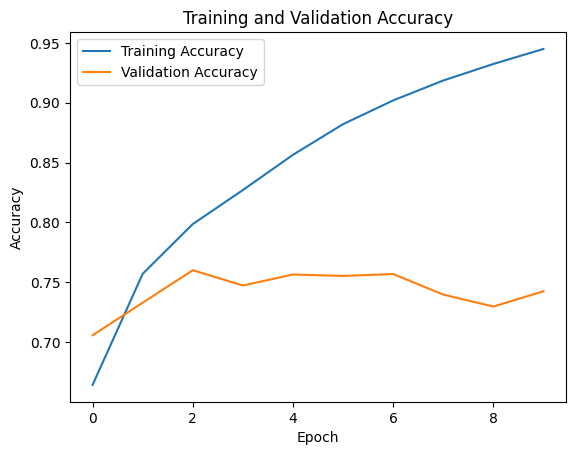

In [13]:

plt.plot(results.history['accuracy'], label='Training Accuracy')
plt.plot(results.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

<B> Evaluerar vår klassificeringsmodell mot testdatasetet

In [14]:
test_loss, test_acc = model.evaluate(test_image_gen)
print(f"Test Accuracy: {test_acc:.4f}")

79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.7440 - loss: 0.6854
Test Accuracy: 0.7332
